# Лабораторная работа №2: Обработка пропусков, кодирование и масштабирование данных

# 1. Подготовка окружения

In [8]:
# Установка зависимостей (если нужно)
# !pip install pandas numpy matplotlib seaborn scikit-learn missingno

# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import missingno as msno

# Настройки визуализации
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

### Загрузка и обзор данных

Размер датасета: (891, 15)

Первые 5 строк:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



Признаки с пропусками:


,Пропуски,Процент
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22


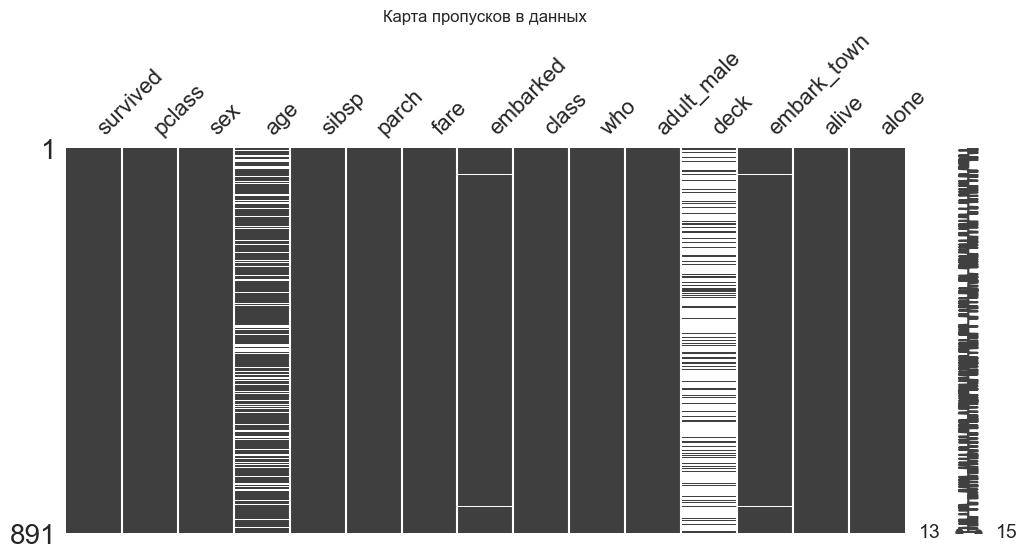


Типы данных:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

Категориальные признаки: ['sex', 'embarked', 'class', 'who', 'deck', 'embark_town', 'alive']


In [9]:
# Загрузка публичного датасета с пропусками (Titanic)
df = sns.load_dataset('titanic')

# Первичный осмотр
print(f"Размер датасета: {df.shape}")
print(f"\nПервые 5 строк:")
display(df.head())

# Статистика пропусков
missing_stats = df.isnull().sum()
missing_percent = (missing_stats / len(df)) * 100
missing_df = pd.DataFrame({
    'Пропуски': missing_stats,
    'Процент': missing_percent.round(2)
}).query('Пропуски > 0').sort_values('Пропуски', ascending=False)

print(f"\nПризнаки с пропусками:")
display(missing_df)

# 🎨 Визуализация пропусков
msno.matrix(df, figsize=(12, 5))
plt.title('Карта пропусков в данных')
plt.show()

# Типы данных и категориальные признаки
print(f"\nТипы данных:\n{df.dtypes}")
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"\nКатегориальные признаки: {categorical_cols}")

# 2. Обработка пропусков

In [10]:
# Разделяем признаки по типам
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Числовые: {numeric_cols}")
print(f"Категориальные: {categorical_cols}")

Числовые: ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
Категориальные: ['sex', 'embarked', 'class', 'who', 'deck', 'embark_town', 'alive']


### Простая стратегия: удаление или заполнение нулями

In [32]:
# Удаление колонок с пропусками
df_drop_cols = df.dropna(axis=1, how='any')
print(f"После удаления колонок: {df.shape} → {df_drop_cols.shape}")

# Удаление строк с пропусками
df_drop_rows = df.dropna(axis=0, how='any')
print(f"После удаления строк: {df.shape} → {df_drop_rows.shape}")

# Заполнение нулями (не всегда корректно!)

# Конвертируем все category → object перед заполнением
df_safe = df.copy()
for col in df_safe.select_dtypes(include='category').columns:
    df_safe[col] = df_safe[col].astype('object')
df_fill_zero = df_safe.fillna(0)
df_fill_zero.head()

После удаления колонок: (891, 15) → (891, 11)
После удаления строк: (891, 15) → (182, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,0,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,0,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,0,Southampton,no,True


### Импьютация - "внедрение значений"

In [11]:
df_imputed = df.copy()

# Числовые признаки: заполняем медианой (устойчива к выбросам)
numeric_imputer = SimpleImputer(strategy='median')
df_imputed[numeric_cols] = numeric_imputer.fit_transform(df[numeric_cols])

# Категориальные признаки: заполняем модой (наиболее частое значение)
categorical_imputer = SimpleImputer(strategy='most_frequent')
df_imputed[categorical_cols] = categorical_imputer.fit_transform(df[categorical_cols])

# ✅ Проверка: пропусков больше нет
print(f"Осталось пропусков: {df_imputed.isnull().sum().sum()}")

Осталось пропусков: 0


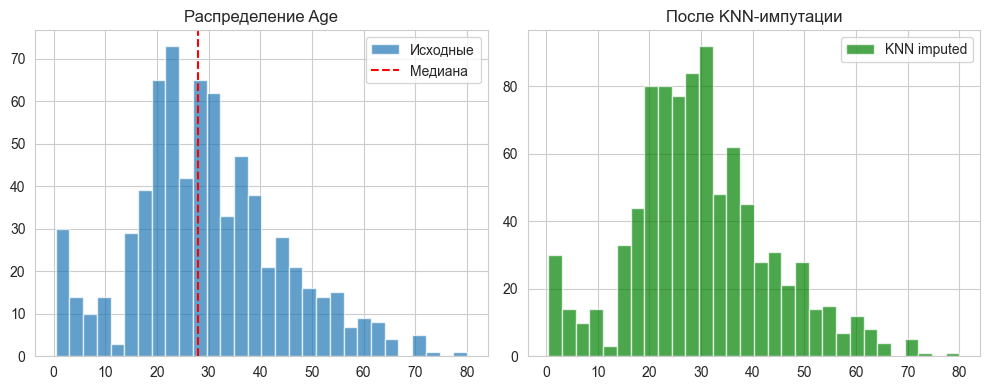

In [12]:
# Только если все признаки числовые или после предварительного кодирования!
# kNN импутация учитывает взаимосвязи между признаками

# Создаём копию только с числовыми данными для KNN
df_numeric = df[numeric_cols].copy()

knn_imputer = KNNImputer(n_neighbors=5)
df_knn = pd.DataFrame(
    knn_imputer.fit_transform(df_numeric),
    columns=numeric_cols,
    index=df.index
)

# Сравнение: медиана vs KNN (на примере одного признака)
if 'age' in numeric_cols:
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.hist(df['age'].dropna(), bins=30, alpha=0.7, label='Исходные')
    plt.axvline(df['age'].median(), color='red', linestyle='--', label='Медиана')
    plt.title('Распределение Age')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.hist(df_knn['age'], bins=30, alpha=0.7, color='green', label='KNN imputed')
    plt.title('После KNN-импутации')
    plt.legend()
    plt.tight_layout()
    plt.show()

# 3. Кодирование категориальных признаков

In [28]:
# Автоматический Label Encoding (без учёта порядка — использовать осторожно!)
label_encoder = LabelEncoder()
for col in categorical_cols:
    # Пропускаем признаки с большим числом уникальных значений (риск переобучения)
    if df_imputed[col].nunique() < 10:
        df_imputed[f'{col}_label'] = label_encoder.fit_transform(df_imputed[col])

In [35]:
for col in categorical_cols:
    # Пропускаем, если уникальных значений слишком много
    if df_imputed[col].nunique() < 10 and df_imputed[col].nunique() > 1:
        # Создаём словарь: категория → число
        unique_vals = df_imputed[col].dropna().unique()
        encoding_dict = {val: idx for idx, val in enumerate(sorted(unique_vals))}

        # Применяем маппинг
        df_imputed[f'{col}_ordinal'] = df_imputed[col].map(encoding_dict).fillna(-1).astype(int)

        print(f"✅ {col}_ordinal: {encoding_dict}")

✅ sex_ordinal: {'female': 0, 'male': 1}
✅ embarked_ordinal: {'C': 0, 'Q': 1, 'S': 2}
✅ class_ordinal: {'First': 0, 'Second': 1, 'Third': 2}
✅ who_ordinal: {'child': 0, 'man': 1, 'woman': 2}
✅ deck_ordinal: {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6}
✅ embark_town_ordinal: {'Cherbourg': 0, 'Queenstown': 1, 'Southampton': 2}
✅ alive_ordinal: {'no': 0, 'yes': 1}


In [29]:
# One-Hot для признаков с небольшим числом категорий
df_encoded = pd.get_dummies(
    df_imputed,
    columns=[col for col in categorical_cols if df_imputed[col].nunique() < 10],
    drop_first=True,  # Убираем мультиколлинеарность
    dtype=int
)

print(f"Размер после кодирования: {df_encoded.shape}")
print(f"Пример новых столбцов: {[c for c in df_encoded.columns if 'sex' in c or 'embarked' in c][:5]}")

Размер после кодирования: (891, 31)
Пример новых столбцов: ['sex_label', 'embarked_label', 'sex_male', 'embarked_Q', 'embarked_S']


In [30]:
# Создаём препроцессинг-пайплайн для продакшена
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())  # Сразу масштабируем числовые
        ]), numeric_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first'))
        ]), categorical_cols)
    ]
)

# Применение (на примере)
# X_preprocessed = preprocessor.fit_transform(df)

# 4. Масштабирование

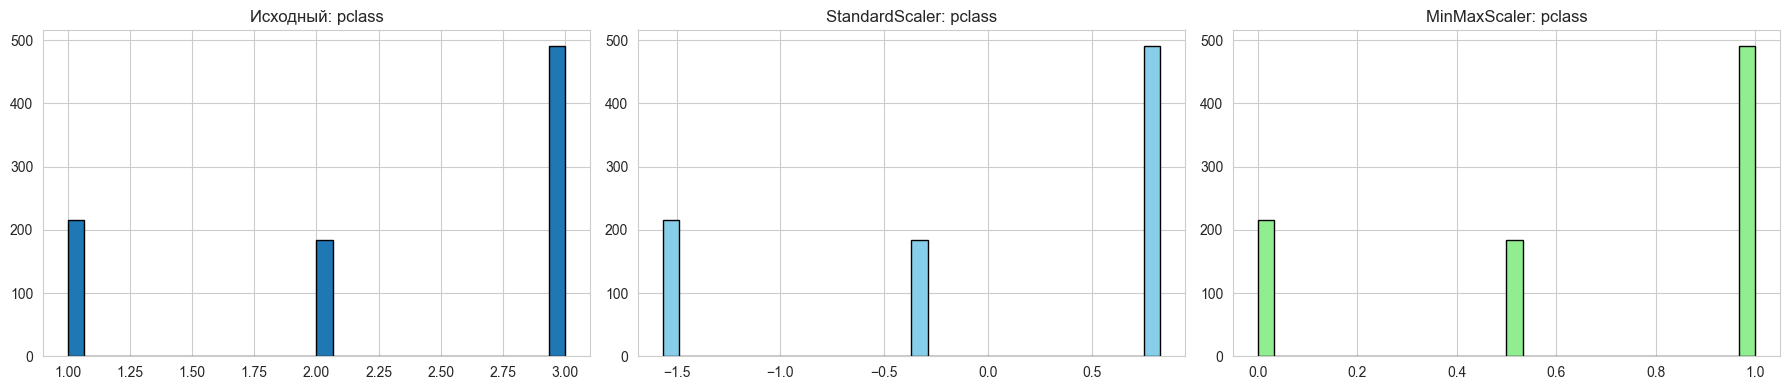

После StandardScaler — mean: -0.0000, std: 1.0006
После MinMaxScaler — min: 0.0000, max: 1.0000


In [25]:
# Выделяем только числовые признаки для масштабирования
numeric_features = df_encoded.select_dtypes(include=[np.number]).columns.tolist()

# 🔹 StandardScaler
scaler_std = StandardScaler()
df_scaled_std = df_encoded.copy()
df_scaled_std[numeric_features] = scaler_std.fit_transform(df_encoded[numeric_features])

# 🔹 MinMaxScaler
scaler_minmax = MinMaxScaler()
df_scaled_minmax = df_encoded.copy()
df_scaled_minmax[numeric_features] = scaler_minmax.fit_transform(df_encoded[numeric_features])

# 📊 Сравнение распределений до и после
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sample_col = [c for c in numeric_features if c != 'survived'][0]  # Берём первый признак, не таргет

axes[0].hist(df_encoded[sample_col], bins=30, edgecolor='black')
axes[0].set_title(f'Исходный: {sample_col}')

axes[1].hist(df_scaled_std[sample_col], bins=30, color='skyblue', edgecolor='black')
axes[1].set_title(f'StandardScaler: {sample_col}')

axes[2].hist(df_scaled_minmax[sample_col], bins=30, color='lightgreen', edgecolor='black')
axes[2].set_title(f'MinMaxScaler: {sample_col}')

plt.tight_layout()
plt.show()

# ✅ Проверка: после StandardScaler mean≈0, std≈1
print(f"После StandardScaler — mean: {df_scaled_std[sample_col].mean():.4f}, std: {df_scaled_std[sample_col].std():.4f}")
print(f"После MinMaxScaler — min: {df_scaled_minmax[sample_col].min():.4f}, max: {df_scaled_minmax[sample_col].max():.4f}")

# 5. Обработка результатов

In [26]:
# 💾 Сохранение обработанного датасета
df_final = df_scaled_std.copy()  # или df_scaled_minmax

# Добавляем таргет, если он есть (например, 'survived')
if 'survived' in df_final.columns:
    df_final['target'] = df_final['survived']
    df_final = df_final.drop(columns=['survived'])

# Сохраняем в CSV
df_final.to_csv('processed_dataset.csv', index=False)
print(f"✅ Датасет сохранён: processed_dataset.csv, размер: {df_final.shape}")

# 📄 Экспорт отчёта о пропусках (для титульного листа / приложения)
report = f"""
Отчёт по обработке данных
========================
Исходный размер: {df.shape}
После обработки: {df_final.shape}

Пропуски по признакам (исходные):
{missing_df.to_markdown()}

Применённые методы:
- Импутация: медиана (числовые), мода (категориальные)
- Кодирование: One-Hot Encoding (drop_first=True)
- Масштабирование: StandardScaler
"""
print(report)

✅ Датасет сохранён: processed_dataset.csv, размер: (891, 31)

Отчёт по обработке данных
Исходный размер: (891, 15)
После обработки: (891, 31)

Пропуски по признакам (исходные):
|             |   Пропуски |   Процент |
|:------------|-----------:|----------:|
| deck        |        688 |     77.22 |
| age         |        177 |     19.87 |
| embarked    |          2 |      0.22 |
| embark_town |          2 |      0.22 |

Применённые методы:
- Импутация: медиана (числовые), мода (категориальные)
- Кодирование: One-Hot Encoding (drop_first=True)
- Масштабирование: StandardScaler

